In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
data = pd.read_csv("results/summary.csv")

In [4]:
data

,matchup,player1,player2,p1_wins,p2_wins,draws,total,p1_win_pct,p2_win_pct,draw_pct
0,Dreamer_vs_SAC,Dreamer,SAC,503,460,37,1000,50.3,46.0,3.7
1,Dreamer_vs_TD3,Dreamer,TD3,442,306,252,1000,44.2,30.6,25.2
2,TD3_vs_SAC,TD3,SAC,679,232,89,1000,67.9,23.2,8.9
3,Dreamer_vs_WeakBot,Dreamer,WeakBot,980,3,17,1000,98.0,0.3,1.7
4,Dreamer_vs_StrongBot,Dreamer,StrongBot,975,5,20,1000,97.5,0.5,2.0
5,TD3_vs_WeakBot,TD3,WeakBot,767,23,210,1000,76.7,2.3,21.0
6,TD3_vs_StrongBot,TD3,StrongBot,775,62,163,1000,77.5,6.2,16.3
7,SAC_vs_WeakBot,SAC,WeakBot,598,40,362,1000,59.8,4.0,36.2
8,SAC_vs_StrongBot,SAC,StrongBot,875,71,54,1000,87.5,7.1,5.4


In [5]:
data["Winrate"] = data["p1_win_pct"] + 0.5* data["draw_pct"]

In [6]:
df = data[["player1", "player2", "Winrate"]]

In [7]:
test_df = df.iloc[:3]
test_df["Winrate"] = 100-test_df["Winrate"]
test_df = test_df.rename(columns={"player2":"player1", "player1":"player2"})

In [8]:
matches = pd.concat([df, test_df]).reset_index().drop("index", axis=1)

In [9]:
# matches["Winrate"] /= 100

In [10]:
matches

,player1,player2,Winrate
0,Dreamer,SAC,52.15
1,Dreamer,TD3,56.80
2,TD3,SAC,72.35
3,Dreamer,WeakBot,98.85
4,Dreamer,StrongBot,98.50
5,TD3,WeakBot,87.20
6,TD3,StrongBot,85.65
7,SAC,WeakBot,77.90
8,SAC,StrongBot,90.20
9,SAC,Dreamer,47.85


In [11]:
matches_pivot = matches.pivot(index="player1", columns="player2", values="Winrate")
matches_pivot = matches_pivot.iloc[[2, 1, 0], [4, 2, 3, 1, 0]]
matches_pivot

player2,WeakBot,StrongBot,TD3,SAC,Dreamer
player1,,,,,
TD3,87.20,85.65,NaN,72.35,43.20
SAC,77.90,90.20,27.65,NaN,47.85
Dreamer,98.85,98.50,56.80,52.15,NaN


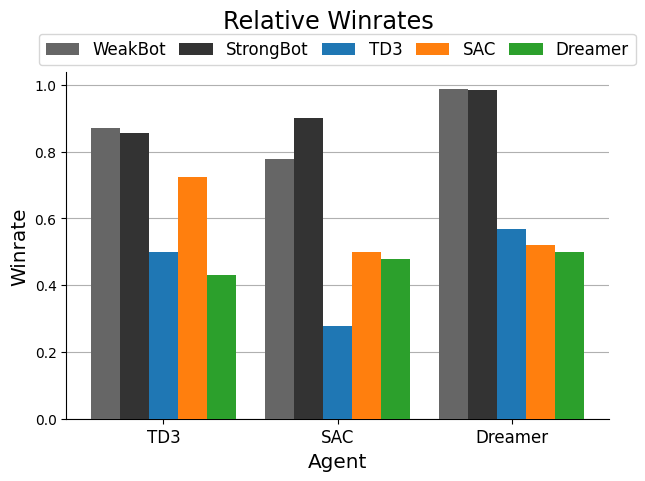

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))
ax.grid(True, axis='y', zorder=-12)
x = np.arange(3)
width = 1/6
colors = ["#666666", "#333333", "tab:blue", "tab:orange", "tab:green"]
for i, (a, y) in enumerate(matches_pivot.fillna(50).items()):
    plt.bar(x + (i-2)*width, y / 100, width = width, label=a, color=colors[i], zorder=10)

# ax.legend(loc='upper center', ncol=5, bbox_to_anchor=(0., 1., 0., 0.))
# ax.hlines(xmin=-0.5, xmax=2.5, y=0.5, color="black", linestyles="--")
ax.legend(columnspacing=0.8, fontsize='large', bbox_to_anchor=(-0.05, 1.02, 1., .102), loc='lower left',ncols=5, borderaxespad=0.)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xticks(x, matches_pivot.index, fontsize='large')
fig.suptitle("Relative Winrates", fontsize='xx-large', y=1.02)
ax.set_xlabel("Agent", fontsize='x-large')
ax.set_ylabel("Winrate", fontsize='x-large')
plt.savefig("comp.png", dpi=200, bbox_inches="tight")

In [13]:
matches_pivot.fillna(50)

player2,WeakBot,StrongBot,TD3,SAC,Dreamer
player1,,,,,
TD3,87.20,85.65,50.00,72.35,43.20
SAC,77.90,90.20,27.65,50.00,47.85
Dreamer,98.85,98.50,56.80,52.15,50.00


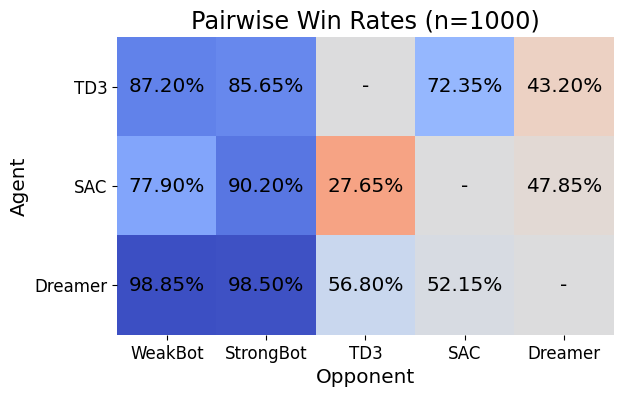

In [19]:
plt.imshow(matches_pivot.fillna(50) / 100, cmap="coolwarm_r", vmin=0, vmax=1)
plt.xticks(range(5), matches_pivot.columns, fontsize='large')
plt.yticks(range(3), matches_pivot.index, fontsize='large')
for i in range(len(matches_pivot.index)):
    for j in range(len(matches_pivot.columns)):
        if np.isnan(matches_pivot.iloc[i, j]):
            text_val = "-"
        else:
            text_val = f"{matches_pivot.iloc[i, j]:.2f}%"
        text = plt.text(j, i, text_val,
                       ha="center", va="center", color="black", fontsize='x-large')
plt.title("Pairwise Win Rates (n=1000)", fontsize='xx-large')
plt.xlabel('Opponent', fontsize='x-large')
plt.ylabel('Agent', fontsize='x-large')
plt.gca().spines[['top', 'right', 'bottom', 'left']].set_visible(False)
plt.savefig("winmatrix.png", dpi=200, bbox_inches="tight")

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (3,) and arg 1 with shape (3, 5).

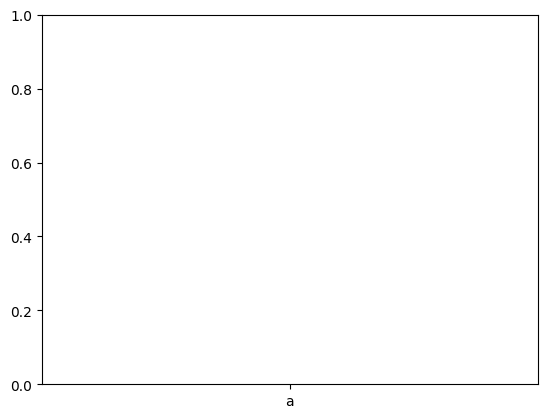

In [10]:
plt.bar(x = ["a", "b", "c"], height=np.arange(15).reshape(3, 5))